In [23]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import shap
import joblib

In [4]:
df = pd.read_csv("../Data/Processed/Processed_data.csv")

In [6]:
# FINALIZED FEATURES 
features = ['unique_word_ratio', 'avg_sentence_length', 'review_length', 'has_digits']

X = df[features]
y = df['target']

In [7]:
# TRAIN TEST SPLIT 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (32345, 4) | Test: (8087, 4)


In [8]:
# DEFINING MODELS 
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])

In [11]:
#  TRAINING INDIVIDUALLY FIRST 
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)

Training XGBoost...
Training Random Forest...
Training Logistic Regression...


Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000))])

In [10]:
# INDIVIDUAL MODEL EVALUATION 
for name, model in [('XGBoost', xgb_model),
                     ('Random Forest', rf_model),
                     ('Logistic Regression', lr_model)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {auc:.4f}")


── XGBoost ──
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4044
           1       0.81      0.83      0.82      4043

    accuracy                           0.82      8087
   macro avg       0.82      0.82      0.82      8087
weighted avg       0.82      0.82      0.82      8087

ROC-AUC: 0.9049

── Random Forest ──
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4044
           1       0.81      0.83      0.82      4043

    accuracy                           0.82      8087
   macro avg       0.82      0.82      0.82      8087
weighted avg       0.82      0.82      0.82      8087

ROC-AUC: 0.9045

── Logistic Regression ──
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      4044
           1       0.77      0.75      0.76      4043

    accuracy                           0.76      8087
   macro avg       0.76      0.76

In [12]:
# VOTING ENSEMBLE 
ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model),
        ('lr', lr_model)
    ],
    voting='soft'
)
ensemble.fit(X_train, y_train)

y_pred_ens = ensemble.predict(X_test)
y_prob_ens = ensemble.predict_proba(X_test)[:, 1]

print("\n── Voting Ensemble ──")
print(classification_report(y_test, y_pred_ens))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_ens):.4f}")


── Voting Ensemble ──
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      4044
           1       0.81      0.82      0.82      4043

    accuracy                           0.82      8087
   macro avg       0.82      0.82      0.82      8087
weighted avg       0.82      0.82      0.82      8087

ROC-AUC: 0.9024


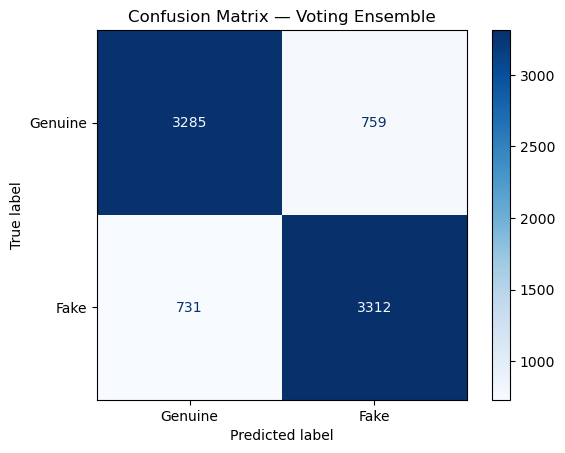

In [13]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_ens)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine', 'Fake'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Voting Ensemble')
plt.show()

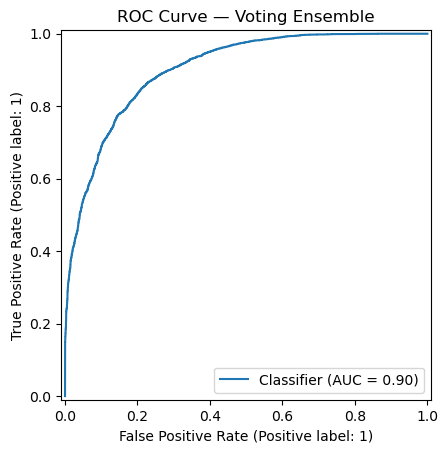

In [14]:
# ROC CURVE 
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob_ens)
plt.title('ROC Curve — Voting Ensemble')
plt.show()

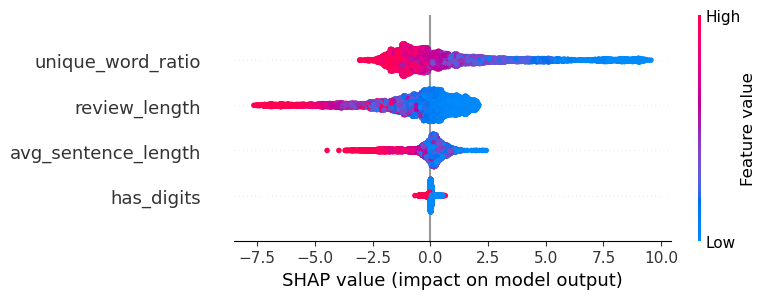

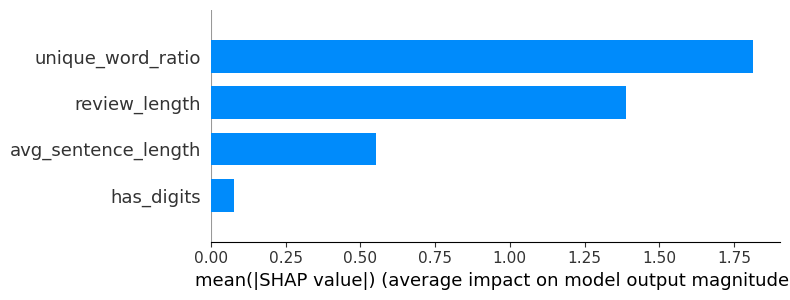

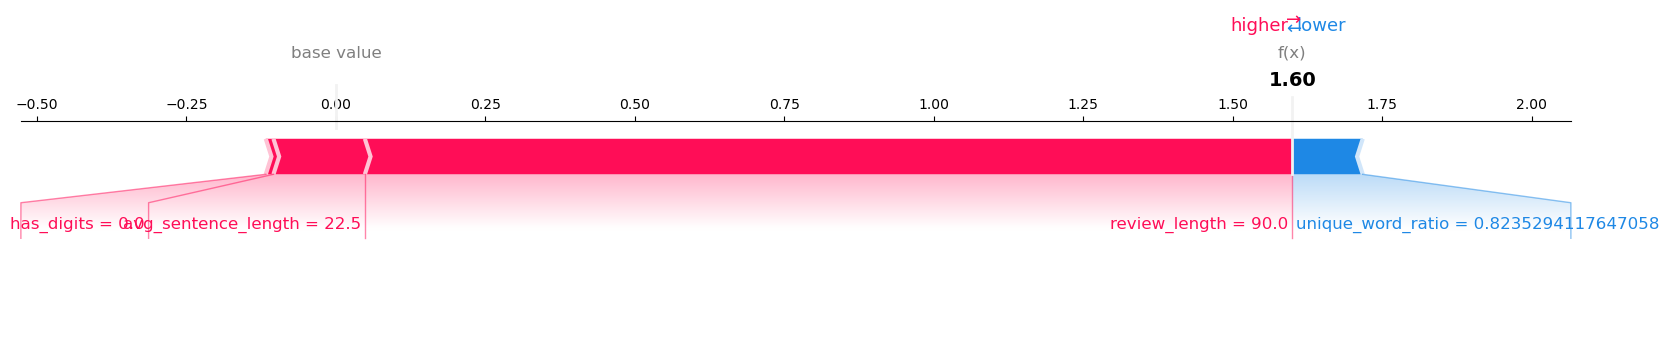

In [24]:
# Use XGBoost standalone (best model)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# ── Plot 1: Summary Plot (Feature Importance) ─────────────
shap.summary_plot(shap_values, X_test, feature_names=features)

# ── Plot 2: Bar Plot (Mean Absolute SHAP) ─────────────────
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type='bar')

# ── Plot 3: Single Prediction Explanation ─────────────────
# Explain first test sample
shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    feature_names=features,
    matplotlib=True
)
plt.show()

In [20]:
# Saving the best model (XGBoost)
joblib.dump(xgb_model, '../Model/reviewshield_model.pkl')

['reviewshield_model.pkl']

In [21]:
# Saving the feature list too
joblib.dump(features, '../Model/features.pkl')

print("Model saved successfully!")

Model saved successfully!


In [22]:
# Testing loading it back
loaded_model = joblib.load('../Model/reviewshield_model.pkl')
loaded_features = joblib.load('../Model/features.pkl')

# Quick sanity check
test_pred = loaded_model.predict(X_test[:5])
print("Test predictions:", test_pred)
print("Actual labels:   ", y_test[:5].values)

Test predictions: [1 1 1 0 1]
Actual labels:    [1 0 1 0 0]
